In [26]:
import librosa
import numpy

import os
from pathlib import Path

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader,TensorDataset
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot

In [29]:
#hyperparameters
BATCH_SIZE=15
epochs=150
learning_rate=1e-3
latent_dim=128
number_of_clusters=4

In [25]:
current_dir = Path().resolve()
base_dir= Path().resolve().parent
DATASET_PATH = base_dir/ "data" / "songs"



In [6]:
dataset=os.listdir(DATASET_PATH)
len(os.listdir(DATASET_PATH))

60

In [7]:
melspectrogram=[]
for data in dataset:
    song_path=os.path.join(DATASET_PATH,data)
    y,sr=librosa.load(song_path,duration=30)  # Load MP3 and automatically decode to waveform
    # print(y)
    # melspectrogram=librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128)
    melspectrogram.append(librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128))
    # print(melspectrogram.shape)
print(melspectrogram,'melspectrogram')

# Convert to log scale (VERY IMPORTANT)
mel_db=librosa.power_to_db(melspectrogram,ref=numpy.max)   
# print(mel_db.dtype)
print(mel_db.shape)

# Normalize 
mel_db = (mel_db - numpy.mean(mel_db)) / numpy.std(mel_db)
print(mel_db.shape)

c:\Users\PC\Desktop\project_CSE715_18101194_anika_ahsan\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[array([[0.0000000e+00, 0.0000000e+00, 2.2722055e-41, ..., 1.4837235e-01,
        1.1153816e-01, 1.5939657e-01],
       [0.0000000e+00, 0.0000000e+00, 5.3451129e-41, ..., 7.8523144e-02,
        8.5061960e-02, 4.8721308e-01],
       [0.0000000e+00, 0.0000000e+00, 7.0957550e-41, ..., 1.0134548e-01,
        4.9097782e-01, 1.2760096e+00],
       ...,
       [0.0000000e+00, 0.0000000e+00, 1.9057659e-43, ..., 1.9952029e-04,
        2.9906115e-04, 5.0159474e-04],
       [0.0000000e+00, 0.0000000e+00, 8.8281803e-44, ..., 1.5682852e-04,
        9.8346733e-05, 3.4017925e-04],
       [0.0000000e+00, 0.0000000e+00, 1.3172206e-43, ..., 9.8546261e-06,
        6.1958899e-06, 1.3983835e-04]], shape=(128, 1292), dtype=float32), array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.15115866e-01, 1.82272214e-02, 8.27206671e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.70022810e-01, 5.82266562e-02, 1.09952450e-01],
       [0.00000000e+00, 0.00000000e+00, 0.0

In [9]:
# 2D-->1D
# Flatten each song separately
mel_flat= mel_db.reshape(mel_db.shape[0], -1)

# mel_flat = mel_db.flatten()
print(mel_flat )
print(mel_flat.shape )



input_dimension=mel_flat.shape[1]
print(input_dimension)


[[-1.4192072  -1.4192072  -1.4192072  ... -1.4192072  -1.4192072
  -1.2954316 ]
 [-1.4192072  -1.4192072  -1.4192072  ... -1.4192072  -1.4192072
  -1.1656176 ]
 [-1.4192072  -1.4192072  -1.4192072  ... -1.1931314  -0.6547387
  -0.48296243]
 ...
 [-1.4192072  -1.4192072  -1.4192072  ... -1.1770662  -1.2200683
  -0.8323768 ]
 [-1.4192072  -1.4192072  -1.4192072  ... -0.46010435 -0.40577143
  -0.35327083]
 [-1.4192072  -1.4192072  -1.0098273  ... -1.4192072  -1.4192072
  -1.4192072 ]]
(60, 165376)
165376


In [11]:
#device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [13]:
#creating batches

print(mel_flat.shape)

#numpy array to tensor
dataset_tensor=torch.tensor(mel_flat, dtype=torch.float32)
dataset = TensorDataset(dataset_tensor)
train_dataset=DataLoader(dataset=dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=True)

print(train_dataset)



###
# X_tensor = torch.tensor(X, dtype=torch.float32)
# dataset = TensorDataset(X_tensor)
# loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)



(60, 165376)


In [14]:
#VAE model

input_dimension=input_dimension

class VAE(nn.Module):
    def __init__(self,input_dim=input_dimension,hidden_dim=256,latent_dim=latent_dim):
        super().__init__()

        #encoder layers
        self.fully_connected_layer_1=nn.Linear(input_dim,512)
        self.fully_connected_layer_2=nn.Linear(512,256)
         
        #mean and log(variance) computation of encoder 
        self.mu=nn.Linear(256,latent_dim)
        self.logvar=nn.Linear(256,latent_dim)

        
        #decoder layers
        self.fully_connected_layer_3=nn.Linear(latent_dim,256)
        self.fully_connected_layer_4=nn.Linear(256,512)
        self.fully_connected_layer_5=nn.Linear(512,input_dim)



        #activation function
        self.relu=nn.ReLU()
        self.sigmoid=nn.Sigmoid()

    def encoder(self,x):
        hidden_layer_1=self.relu(self.fully_connected_layer_1(x))
        hidden_layer_2=self.relu(self.fully_connected_layer_2(hidden_layer_1))
        mu=self.mu(hidden_layer_2)
        logvar=self.logvar(hidden_layer_2)
        return mu,logvar

    def reparameterization(self,mu,logvar):
        standard_deviation=torch.exp(0.5*logvar)
        epsilon=torch.randn_like(standard_deviation)
        z=mu + epsilon*standard_deviation
        return z

    def decoder(self,z):
        hidden_layer_3=self.relu( self.fully_connected_layer_3(z))
        hidden_layer_4=self.relu(self.fully_connected_layer_4(hidden_layer_3))
        output=self.sigmoid(self.fully_connected_layer_5(hidden_layer_4))
        return output
        
    
    def forward(self,x):
        mu,logvar=self.encoder(x)  
        z=self.reparameterization(mu,logvar)
        x_reconstructed=self.decoder(z)
        return x_reconstructed, mu,logvar



In [15]:
#loss function
def vae_loss(x_reconstructed,x,mu,logvar):
    reconstruction_loss=nn.functional.mse_loss(x_reconstructed,x)

    reconstruction_loss=nn.functional.mse_loss(x_reconstructed,x)

    # reconstruction_loss=nn.functional.binary_cross_entropy(x_reconstructed,x,reduction='sum')


    kl_loss=0.5*torch.sum(mu.pow(2) + logvar.exp() - logvar -1)

    return reconstruction_loss + kl_loss

In [21]:
model=VAE()  #creating object of class vae
optimizer=optim.Adam(model.parameters(),lr=learning_rate)

In [19]:

# model training
model.train()

for epoch in range(epochs):
    total_loss=0

    for (x,) in (train_dataset):
        
        x = x.to(device)
        # x = x.view(-1,input_dimension).to(device)
        # print(x.shape)
        optimizer.zero_grad()

        x_reconstructed,mu,logvar=model(x)  # x_reconstructed, mu, logvar = model.forward(x)
        loss=vae_loss( x_reconstructed,x,mu,logvar)

        loss.backward()
        optimizer.step()

        total_loss=total_loss + loss.item()

    avg_loss=total_loss/len(train_dataset.dataset)   


    print(f"epoch [{epoch+1}/{epochs},loss:{avg_loss:.4f}]")






epoch [1/150,loss:52.9927]
epoch [2/150,loss:53.0661]
epoch [3/150,loss:54.1616]
epoch [4/150,loss:54.8091]
epoch [5/150,loss:51.1487]
epoch [6/150,loss:51.5860]
epoch [7/150,loss:50.8989]
epoch [8/150,loss:50.0346]
epoch [9/150,loss:49.6732]
epoch [10/150,loss:50.3561]
epoch [11/150,loss:49.6322]
epoch [12/150,loss:47.8265]
epoch [13/150,loss:47.8369]
epoch [14/150,loss:48.0211]
epoch [15/150,loss:46.8117]
epoch [16/150,loss:46.0731]
epoch [17/150,loss:45.8968]
epoch [18/150,loss:45.6201]
epoch [19/150,loss:45.2601]
epoch [20/150,loss:45.4987]
epoch [21/150,loss:43.9849]
epoch [22/150,loss:43.3833]
epoch [23/150,loss:43.7528]
epoch [24/150,loss:43.6595]
epoch [25/150,loss:43.8983]
epoch [26/150,loss:44.0208]
epoch [27/150,loss:43.1954]
epoch [28/150,loss:43.2993]
epoch [29/150,loss:43.6206]
epoch [30/150,loss:42.2799]
epoch [31/150,loss:42.0462]
epoch [32/150,loss:41.9367]
epoch [33/150,loss:41.9062]
epoch [34/150,loss:40.7190]
epoch [35/150,loss:41.2879]
epoch [36/150,loss:40.5621]
e

In [22]:
#latent features extraction
model.eval()

latent_features=[]
with torch.no_grad():
     for (x,) in (train_dataset):
          x=x.to(device)
          x_reconstructed,mu,logvar=model(x)
          latent_features.append(mu.cpu().numpy())
          
# print(latent_features)
latent_representation = numpy.vstack(latent_features)    
print(latent_representation)      

          
          


[[ 0.0522753  -0.0835079  -0.02778414 ...  0.11457606 -0.03056343
  -0.13055365]
 [ 0.0993809   0.00679001  0.14774093 ...  0.14306541 -0.03715186
   0.00219656]
 [ 0.00046371 -0.04783702  0.08163106 ...  0.09311042 -0.01199972
  -0.09842154]
 ...
 [ 0.05734359 -0.08345859  0.12394414 ...  0.2304398  -0.05920983
  -0.10800274]
 [ 0.03128604 -0.05502459  0.11104093 ...  0.13160798 -0.1757217
  -0.12457891]
 [ 0.09626985  0.00720574  0.05754391 ...  0.21152522 -0.03695219
   0.00236667]]


In [30]:
# k means clustering

k_means=KMeans(n_clusters=number_of_clusters,random_state=42)
labels=k_means.fit_predict(latent_representation)
labels

array([3, 1, 1, 2, 3, 3, 2, 1, 1, 2, 3, 2, 2, 1, 2, 3, 3, 3, 3, 3, 1, 1,
       0, 3, 1, 1, 3, 1, 0, 3, 3, 2, 1, 2, 0, 2, 2, 2, 3, 0, 2, 1, 1, 1,
       1, 1, 2, 2, 2, 1, 1, 1, 2, 3, 1, 3, 3, 3, 0, 1], dtype=int32)

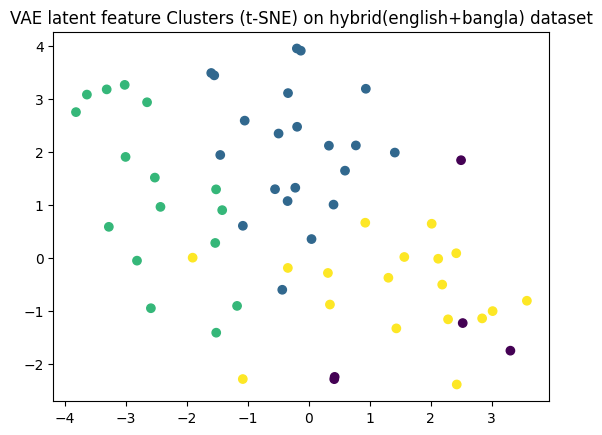

In [38]:
#visualize cluster
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=25)
X_2d = tsne.fit_transform(latent_representation)

plt.scatter(X_2d[:,0], X_2d[:,1], c=labels)
plt.title("VAE latent feature Clusters (t-SNE) on hybrid(english+bangla) dataset")
plt.show()


In [39]:
# Baseline: PCA + K-Means
from sklearn.decomposition import PCA


pca = PCA(n_components=32)
X_pca = pca.fit_transform(mel_flat)


kmeans_pca = KMeans(n_clusters=4)
labels_pca = kmeans_pca.fit_predict(X_pca)




In [44]:
from sklearn.metrics import silhouette_score


silhouette_score_vae = silhouette_score(latent_representation, labels)
silhouette_score_pca = silhouette_score(X_pca, labels_pca)
print(silhouette_score_vae,'silhouette_score_vae')
print(silhouette_score_pca ,'silhouette_score_pca ')

0.049562353640794754 silhouette_score_vae
0.05887886509299278 silhouette_score_pca 


In [45]:
from sklearn.metrics import calinski_harabasz_score

calinski_harabasz_score_vae = calinski_harabasz_score(latent_representation, labels)
calinski_harabasz_score_pca = calinski_harabasz_score(X_pca, labels_pca)
print(calinski_harabasz_score_vae,'calinski_harabasz_score_vae')
print(calinski_harabasz_score_pca ,'calinski_harabasz_score_pca' )

4.557870864868164 calinski_harabasz_score_vae
5.839738368988037 calinski_harabasz_score_pca
